In [4]:
import numpy as np
import scipy as scipy
import scipy.special
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib import colors
import time
import uncertainties as error
import pandas as pd
import emcee
import corner
np.random.seed(12345)

Problem 1

$p(x_t, x_{t+1}) = p(x_t|D)p(x_{t+1}|x_t) = p(x_t|D) q(x_{t+1}|x_t) \alpha(x_t, x_{t+1})$

$\alpha(x_t, x_{t+1}) = \text{min}(1, \frac{p(x_{t+1}|D)}{p(x_t|D)}\frac{q(x_t|x_{t+1})}{q(x_{t+1}|x_t)})$

Show that $p(x_t|D) p(x_{t+1}|x_t) = p(x_{t+1}|D) p(x_t|x_{t+1})$

------------------------------------------------------------------

To do this, we work backwards. We start with $p(x_t|D) p(x_{t+1}|x_t) = p(x_{t+1}|D) p(x_t|x_{t+1})$ and use the fact that $p(x_t, x_{t+1}) = p(x_t|D) q(x_{t+1}|x_t) \alpha(x_t, x_{t+1}) $

$p(x_t|D) p(x_{t+1}|x_t) = p(x_t|D) q(x_{t+1}|x_t) \alpha(x_t, x_{t+1})$

We can also show from the equation of detailed balance that

$p(x_{t+1}, x_{t}) = q(x_{t}|x_{t+1}) \alpha(x_{t+1}, x_{t})$

We note that this has flipped the ordering, and we can write that as

$\alpha(x_t, x_{t+1}) = \text{min}(1, \frac{p(x_t|D)}{p(x_{t+1}|D)}\frac{q(x_{t+1}|x_t)}{q(x_t|x_{t+1})})$

The difference is that the ratio inside the min function is inverted. We now canevaluate the two cases for alpha, one where it equals 1 and the other where it equals that ratio

For $\alpha(x_t, x_{t+1}) = 1$, we know that alpha(x_{t+1}, x_{t}) must be $\frac{p(x_t|D)}{p(x_{t+1}|D)}\frac{q(x_{t+1}|x_t)}{q(x_t|x_{t+1})}$. This can be seen by the fact these 2 functions for alpha are inverses of each other, so when one is small the other must be large. 


Problem 2 (sorry this is a bit of a mess)

In [5]:
#a.)
#Let's start with the log likelyhood of the poission distribution
#Wikipedia thankfully has this so we'll just bring this in
def LogLikelihoodPoission(lambd, k):
    return(-np.sum(lambd) + np.sum(k*np.log(lambd)) - np.sum(scipy.special.gammaln(k+1)))
#gammaln(k+1) = np.log(scipy.special.factorial(k)) since gamma(k+1)=k! and this avoids taking huge factorials

z = np.array([0, 6, 12, 18]) * 1e-4 #cm
n = np.array([1880, 940, 530, 305])

# Constants (cgs units!)
r = 0.52e-4 #cm
delta_rho = 0.063 #g/cm^3
g = 980 #cm/s^2
T = 290 #K

PoissionConstant = ((4/3)*np.pi*r**3 * delta_rho * g) / T #moving all constants to one so function can be 
#expressed in just z, kB, and this constant

def NuofZ(z, nu0, kB): #function defined already
    return(nu0 * np.exp(-PoissionConstant * z / kB))

def LogLikelyhoodWrapper(theta): #Setting this up for emcee handling. Just unpack theta and contrain for physicality
    nu0, kB = theta
    
    if nu0 <= 0 or kB <= 0:
        return -np.inf
    
    nu = NuofZ(z, nu0, kB)
    
    return(LogLikelihoodPoission(nu, n)) #do the log likelyhood if physically allowed


def LogPrior(theta):
    nu0, kB = theta
    
    if((0 < nu0 < 10e4) and (1e-17 < kB < 1e-13)):
        return(0) #in log space so 0 is actually uniform
    return(-np.inf) #kill off all regions outside prior(so uniform inside allowed region)

def LogPosterior(theta):
    return(LogPrior(theta) + LogLikelyhoodWrapper(theta)) #log space so adding logs = multiplying prior to likelyhood

100%|█████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:05<00:00, 973.72it/s]


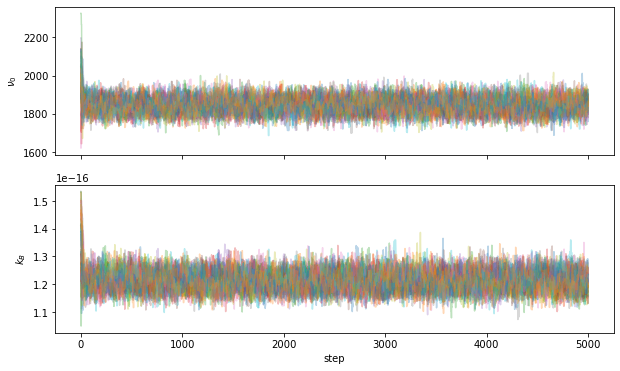

In [6]:
#now we use mcmc
ndim = 2 #kB and nu0
nwalkers = 32 #idk a good number here

nu0_guess = 2000 #need some seed values, this is close to larget n value we have
kB_guess = 1.4e-16

pos = np.array([nu0_guess, kB_guess]) + np.column_stack([ #offsets nu0 and kB guess values by some variation
    100*np.random.randn(nwalkers),
    1e-17*np.random.randn(nwalkers)
])

sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior)
sampler.run_mcmc(pos, 5000, progress=True)

#plotting things
samples = sampler.get_chain() #from an emcee tutorial page
fig, axes = plt.subplots(2, figsize=(10, 6), sharex=True)
axes[0].plot(samples[:, :, 0], alpha=0.3)
axes[0].set_ylabel(r"$\nu_0$")
axes[1].plot(samples[:, :, 1], alpha=0.3)
axes[1].set_ylabel(r"$k_B$")
axes[1].set_xlabel("step")
plt.show()

#ooo ok this is showing agreement

[31.92974199 31.23989921]
(10464, 2)


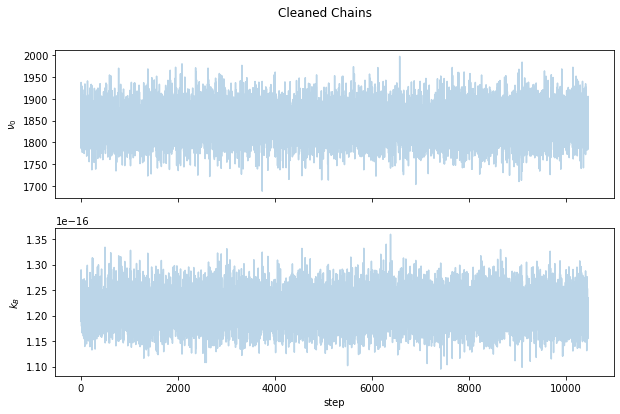

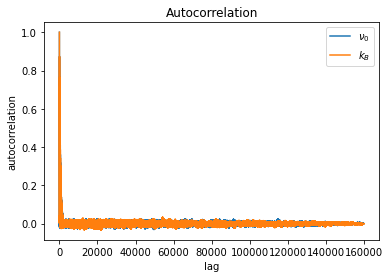

In [17]:
#b.)
#We plot the autocorrelation function and discard burn-in(and thin)

tau = sampler.get_autocorr_time()
print(tau)

flat_samples = sampler.get_chain(discard=int(3*tau[0]), thin=int(tau[0]/2), flat=True)
print(flat_samples.shape)

fig, axes = plt.subplots(2, figsize=(10, 6), sharex=True)
fig.suptitle('Cleaned Chains')
axes[0].plot(flat_samples[:, 0], alpha=0.3)
axes[0].set_ylabel(r"$\nu_0$")
axes[1].plot(flat_samples[:, 1], alpha=0.3)
axes[1].set_ylabel(r"$k_B$")
axes[1].set_xlabel("step")
plt.show()

#Showing the actual autocorrelation function

acf_nu0 = emcee.autocorr.function_1d(samples[:, :, 0].reshape(-1)) #thanks emcee
acf_kB  = emcee.autocorr.function_1d(samples[:, :, 1].reshape(-1))
plt.plot(acf_nu0, label=r"$\nu_0$")
plt.plot(acf_kB, label=r"$k_B$")
plt.title('Autocorrelation')
plt.xlabel("lag")
plt.ylabel("autocorrelation")
plt.legend()
plt.show()

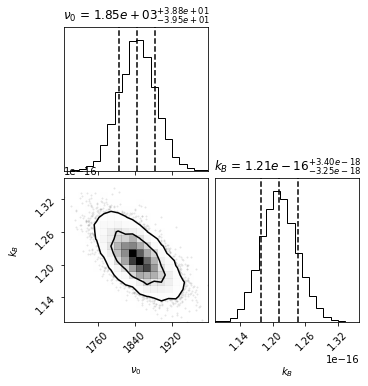

In [24]:
#c.)
#We make a corner plot for the data
fig = corner.corner(flat_samples, show_titles=True, quantiles=[0.16, 0.5, 0.84], levels=(0.68, 0.95), labels=[r"$\nu_0$", r"$k_B$"], title_fmt=".2e")

#OK histograms should be showing the MPV as well as the 1sigma or 68% bounds. Off-diagonal has 1 and 2 sigma contours
#We see there is a correlation between nu0 and kB. In general for larger nu0, we get a lower kB
#this can be seen by the trend having a negative slope and being pretty clustered on it

In [34]:
#d.)
#We calculate N_A = R/kB
R=8.32 * 10**7 #erg mol−1 K−1 

kB_samples = flat_samples[:, 1]
NA_samples = R / kB_samples

NA_low, NA_med, NA_high = np.percentile(NA_samples, [16, 50, 84])

print('Avagadro\'s number:', NA_med, '+/-', (NA_high-NA_low)/2)
#ok so this is a couple sigma off. 6.02E23 is the accepted number, and we have 6.86 +/- 0.188 E23 so we are 4.46 sigma off
#there are likely some big systematics in the raw data. I think it would be extremely hard to get accurate counts
#by eye through the microscope because all the particles should be moving into and out of focus

Avagadro's number: 6.86547538753443e+23 +/- 1.8803369331466047e+22


100%|█████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:16<00:00, 303.32it/s]


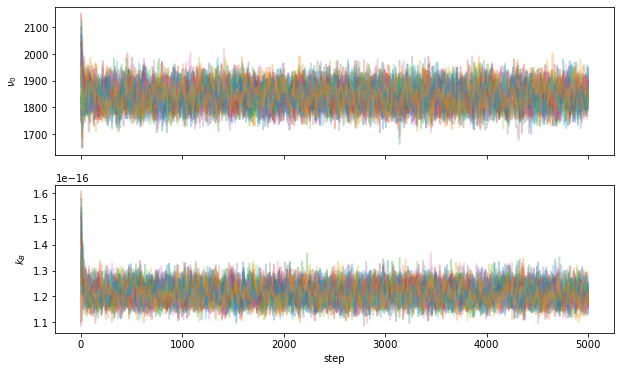

[28.24146724 29.196821  ]
(11232, 2)


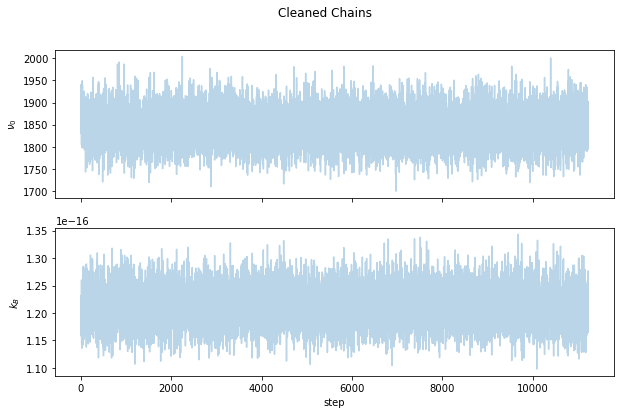

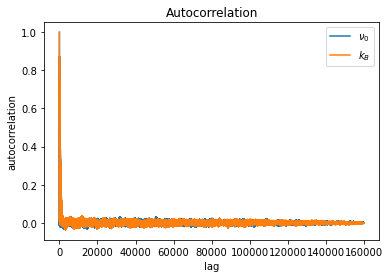

Avagadro's number: 6.86752534846292e+23 +/- 1.9046758174792996e+22


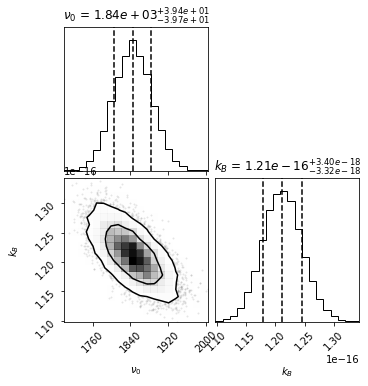

In [39]:
#e.)
#We remake with new priors

#a.)
#Let's start with the log likelyhood of the poission distribution
#Wikipedia thankfully has this so we'll just bring this in
def LogLikelihoodPoission(lambd, k):
    return(-np.sum(lambd) + np.sum(k*np.log(lambd)) - np.sum(scipy.special.gammaln(k+1)))
#gammaln(k+1) = np.log(scipy.special.factorial(k)) since gamma(k+1)=k! and this avoids taking huge factorials

z = np.array([0, 6, 12, 18]) * 1e-4 #cm
n = np.array([1880, 940, 530, 305])

# Constants (cgs units!)
r = 0.52e-4 #cm
delta_rho = 0.063 #g/cm^3
g = 980 #cm/s^2
T = 290 #K

PoissionConstant = ((4/3)*np.pi*r**3 * delta_rho * g) / T #moving all constants to one so function can be 
#expressed in just z, kB, and this constant

def NuofZ(z, nu0, kB): #function defined already
    return(nu0 * np.exp(-PoissionConstant * z / kB))

def LogLikelyhoodWrapper(theta): #Setting this up for emcee handling. Just unpack theta and contrain for physicality
    nu0, kB = theta
    
    if nu0 <= 0 or kB <= 0:
        return -np.inf
    
    nu = NuofZ(z, nu0, kB)
    
    return(LogLikelihoodPoission(nu, n)) #do the log likelyhood if physically allowed


def LogPrior(theta):
    nu0, kB = theta

    if (0 < nu0 < 1e5) and (1e-17 < kB < 1e-13):
        return -np.log(kB)   #Jeffreys prior for kB is 1/kB, so in log space it is log(1/kB)=-log(kB)
    #Uniform in nu0 still means a constant, which we can pick 0 for
    return -np.inf

def LogPosterior(theta):
    return(LogPrior(theta) + LogLikelyhoodWrapper(theta)) #log space so adding logs = multiplying prior to likelyhood

#now we use mcmc
ndim = 2 #kB and nu0
nwalkers = 32 #idk a good number here

nu0_guess = 2000 #need some seed values, this is close to larget n value we have
kB_guess = 1.4e-16

pos = np.array([nu0_guess, kB_guess]) + np.column_stack([ #offsets nu0 and kB guess values by some variation
    100*np.random.randn(nwalkers),
    1e-17*np.random.randn(nwalkers)
])

sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior)
sampler.run_mcmc(pos, 5000, progress=True)

#plotting things
samples = sampler.get_chain() #from an emcee tutorial page
fig, axes = plt.subplots(2, figsize=(10, 6), sharex=True)
axes[0].plot(samples[:, :, 0], alpha=0.3)
axes[0].set_ylabel(r"$\nu_0$")
axes[1].plot(samples[:, :, 1], alpha=0.3)
axes[1].set_ylabel(r"$k_B$")
axes[1].set_xlabel("step")
plt.show()

#ooo ok this is showing agreement

#b.)
#We plot the autocorrelation function and discard burn-in(and thin)

tau = sampler.get_autocorr_time()
print(tau)

flat_samples = sampler.get_chain(discard=int(3*tau[0]), thin=int(tau[0]/2), flat=True)
print(flat_samples.shape)

fig, axes = plt.subplots(2, figsize=(10, 6), sharex=True)
fig.suptitle('Cleaned Chains')
axes[0].plot(flat_samples[:, 0], alpha=0.3)
axes[0].set_ylabel(r"$\nu_0$")
axes[1].plot(flat_samples[:, 1], alpha=0.3)
axes[1].set_ylabel(r"$k_B$")
axes[1].set_xlabel("step")
plt.show()

#Showing the actual autocorrelation function

acf_nu0 = emcee.autocorr.function_1d(samples[:, :, 0].reshape(-1)) #thanks emcee
acf_kB  = emcee.autocorr.function_1d(samples[:, :, 1].reshape(-1))
plt.plot(acf_nu0, label=r"$\nu_0$")
plt.plot(acf_kB, label=r"$k_B$")
plt.title('Autocorrelation')
plt.xlabel("lag")
plt.ylabel("autocorrelation")
plt.legend()
plt.show()



#c.)
#We make a corner plot for the data
fig = corner.corner(flat_samples, show_titles=True, quantiles=[0.16, 0.5, 0.84], levels=(0.68, 0.95), labels=[r"$\nu_0$", r"$k_B$"], title_fmt=".2e")

#OK histograms should be showing the MPV as well as the 1sigma or 68% bounds. Off-diagonal has 1 and 2 sigma contours
#We see there is a correlation between nu0 and kB. In general for larger nu0, we get a lower kB
#this can be seen by the trend having a negative slope and being pretty clustered on it

#d.)
#We calculate N_A = R/kB
R=8.32 * 10**7 #erg mol−1 K−1 

kB_samples = flat_samples[:, 1]
NA_samples = R / kB_samples

NA_low, NA_med, NA_high = np.percentile(NA_samples, [16, 50, 84])

print('Avagadro\'s number:', NA_med, '+/-', (NA_high-NA_low)/2)\

#Avagadro's number: 6.86752534846292e+23 +/- 1.9046758174792996e+22
#So not a huge improvement. Which makes sense, as the priors only seed the values for the walkers.
#We get the measurement from after the walkers have moved and settled, which is independent of the prior
#So the fact our measurement doesn't seem to be affected by choice of prior is expected and also a good sign
#since measurements being robust to priors are good

In [40]:
#f.)
#6.02214076  x 10^23 mol-1 is the current data from https://physics.nist.gov/cgi-bin/cuu/Value?na
#and Avagadro's number: 6.86752534846292e+23 +/- 1.9046758174792996e+22 is what we just measure

(6.86752534846292e+23-6.02214076e+23)/1.9046758174792996e+22
#We have a significance of 4.4384696897224485 sigma. 
#This probably would be statisitically significant for confirming a number to theory, but particle physics uses 5 sigma
#which means we can sorta be in agreement there(yeah its 5 sigma for confirming a particle discovery which is not
#what this is but this is to say the measurement isn't terribly off at least)

#As I mentioned before, there are some systematics which may influcence this result. For one, how the particles were counted
#If this was done by physically counting, we would expect some error from this due to particles moving up and down
#within an observation. IDK if there was a camera involved with this experiment or not
#We also have to have the particles of a specific radius and density, as well as temperature over the course of measurement
#creating the particles surely was not an exact process, so some of our 'constants' are actually distributions of unknown width
#hence being a systematic uncertianty

4.4384696897224485